In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib

In [2]:
import os
print(os.getcwd())


c:\Users\lijun\Downloads\Sasha-clean\ImageGeneration


In [4]:
def draw_trajectories(data_path='./', out_path='./'): # Initial Drawing Style
    for file in os.listdir(data_path):
        if not file.endswith('.npy'):
            continue

        user = os.path.splitext(file)[0]
        X = np.load(os.path.join(data_path, file))

        save_dir = os.path.join(out_path, user)
        os.makedirs(save_dir, exist_ok=True)

        fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
        for i, seq in enumerate(X):
            non_zero_mask = ~np.all(seq == 0, axis=1)
            non_zero_inds = np.where(non_zero_mask)[0]

            dx = seq[non_zero_inds, 0]
            dy = seq[non_zero_inds, 1]

            xs = np.cumsum(dx)
            ys = np.cumsum(dy)

            ax.clear()
            ax.plot(xs, ys, marker='o', linewidth=2, markersize=3)
            
            ax.set_axis_off()
            ax.set_aspect('equal')

            plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
            plt.savefig(os.path.join(save_dir, f'img{i}.png'), dpi=100)
        plt.close(fig)


**Above is what Charles wrote**


###########################################

**Draw the baseline trajectories**

In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt

def draw_trajectories_baseline(data_path='./', out_path='./'):
    for file in os.listdir(data_path):
        if not file.endswith('.npy'):
            continue

        user = os.path.splitext(file)[0]
        X = np.load(os.path.join(data_path, file))

        save_dir = os.path.join(out_path, user)
        os.makedirs(save_dir, exist_ok=True)

        fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
        for i, seq in enumerate(X):
            non_zero_mask = ~np.all(seq == 0, axis=1)
            non_zero_inds = np.where(non_zero_mask)[0]

            dx = seq[non_zero_inds, 0]
            dy = seq[non_zero_inds, 1]
            xs = np.cumsum(dx)
            ys = np.cumsum(dy)

            ax.clear()
            ax.plot(xs, ys, color='red' , linewidth=2)  # Red line and no marker
            
            ax.set_axis_off()
            ax.set_aspect('equal')
            
            plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
            plt.savefig(os.path.join(save_dir, f'img{i}.png'),
                        dpi=100)

        plt.close(fig)


**Draw the Baseline Images**

-Draw the Basline Images for binary

In [7]:
draw_trajectories_baseline('../Data/binary/', '../Data/image_output_baseline/')

In [ ]:
draw_trajectories('../Data/binary/', '../Data/image_output_Initial_/')

**We don't need this since we will add the negative label by random sampling in the training folder. No need to add the negative label now**

**Start Generation From Here:**

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

def draw_trajectories_baseline(data_path="../Data/binary", out_path="../Data/Images/binary_baseline"):
    os.makedirs(out_path, exist_ok=True)

    for filename in sorted(os.listdir(data_path)):
        if not filename.endswith('.npy'):
            continue

        user_id = filename.replace('.npy', '')
        npy_path = os.path.join(data_path, filename)

        save_dir = os.path.join(out_path, f"user{user_id}")
        os.makedirs(save_dir, exist_ok=True)

        print(f"Processing user{user_id}...")

        X = np.load(npy_path)  # shape: (N, T, 3)

        fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
        for i, seq in enumerate(X):
            non_zero_mask = ~np.all(seq == 0, axis=1)
            non_zero_inds = np.where(non_zero_mask)[0]

            if len(non_zero_inds) == 0:
                continue

            dx = seq[non_zero_inds, 0]
            dy = seq[non_zero_inds, 1]
            xs = np.cumsum(dx)
            ys = np.cumsum(dy)

            ax.clear()
            ax.plot(xs, ys, color='red', linewidth=2)
            ax.set_axis_off()
            ax.set_aspect('equal')
            plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

            img_path = os.path.join(save_dir, f"user{user_id}_img{i}.png")
            plt.savefig(img_path, dpi=100)

        plt.close(fig)

    print("\n All user trajectory images saved to:", out_path)


In [23]:
#draw_trajectories_baseline()

**Draw the Velocity Encoding Images**

-Draw the Velocity Encoding Images with both positive and negative labels

-Find the global maximum velocity and global minimum velcocity from all the sequences first

In [1]:
import os
import numpy as np

def compute_global_velocity_minmax(data_path):
    global_min_v = float('inf')
    global_max_v = float('-inf')

    for fname in sorted(os.listdir(data_path)):
        if not fname.endswith('.npy'):
            continue

        file_path = os.path.join(data_path, fname)
        data = np.load(file_path)

        for seq in data:
            seq = seq[~np.all(seq == 0, axis=1)]
            if len(seq) < 2:
                continue

            dx = seq[:, 0]
            dy = seq[:, 1]
            dt = seq[:, 2]

            with np.errstate(divide='ignore', invalid='ignore'):
                velocity = np.where(dt != 0, np.sqrt(dx**2 + dy**2) / dt, 0)

            if velocity.size > 0:
                global_min_v = min(global_min_v, velocity.min())
                global_max_v = max(global_max_v, velocity.max())

    return global_min_v, global_max_v


In [2]:
min_v, max_v = compute_global_velocity_minmax('../Data/binary')
print(f"Velocity range: min = {min_v:.4f}, max = {max_v:.4f}")


Velocity range: min = 0.0000, max = 1860.0527


In [3]:
import os
import numpy as np

def get_all_velocities(data_path):
    all_velocities = []

    for fname in sorted(os.listdir(data_path)):
        if not fname.endswith('.npy'):
            continue

        file_path = os.path.join(data_path, fname)
        data = np.load(file_path)

        for seq in data:
            seq = seq[~np.all(seq == 0, axis=1)]

            if len(seq) < 2:
                continue

            dx = seq[:, 0]
            dy = seq[:, 1]
            dt = seq[:, 2]

            with np.errstate(divide='ignore', invalid='ignore'):
                velocity = np.where(dt != 0, np.sqrt(dx**2 + dy**2) / dt, 0)

            all_velocities.extend(velocity)

    return np.array(all_velocities)


In [4]:
velocities = get_all_velocities("../Data/binary")


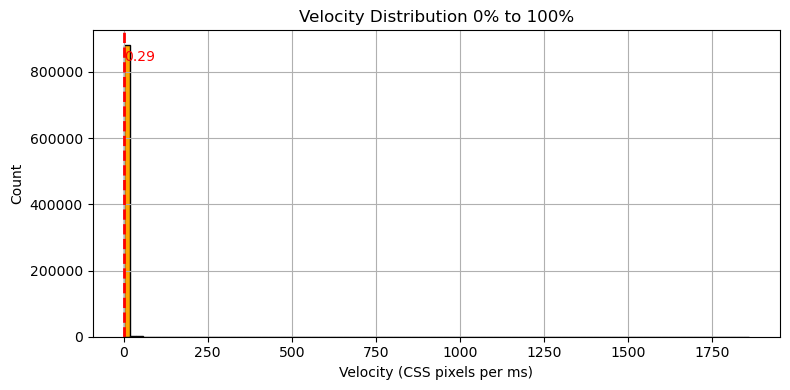

In [6]:
import matplotlib.pyplot as plt
median = np.median(velocities)

plt.figure(figsize=(8, 4))
plt.hist(velocities, bins=100, color='orange', edgecolor='black')
plt.axvline(median, color='red', linestyle='--', linewidth=2, label=f'Median = {median:.2f}')
plt.text(median + 1, plt.ylim()[1] * 0.9, f'{median:.2f}', color='red')
plt.title("Velocity Distribution 0% to 100%")
plt.xlabel("Velocity (CSS pixels per ms)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()

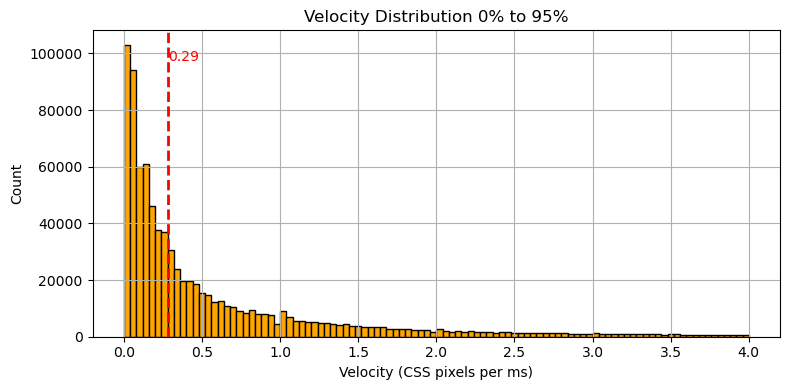

In [7]:

v_iqr1 = velocities[(velocities >= np.percentile(velocities, 0)) & (velocities <= np.percentile(velocities, 95))]

median = np.median(velocities)
v_iqr1 = velocities[(velocities >= 0) & (velocities <= 4)]
plt.figure(figsize=(8, 4))
plt.hist(v_iqr1, bins=100, color='orange', edgecolor='black')
plt.axvline(median, color='red', linestyle='--', linewidth=2, label=f'Median = {median:.2f}')
plt.text(median, plt.ylim()[1] * 0.9, f'{median:.2f}', color='red')
plt.title("Velocity Distribution 0% to 95%")
plt.xlabel("Velocity (CSS pixels per ms)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()



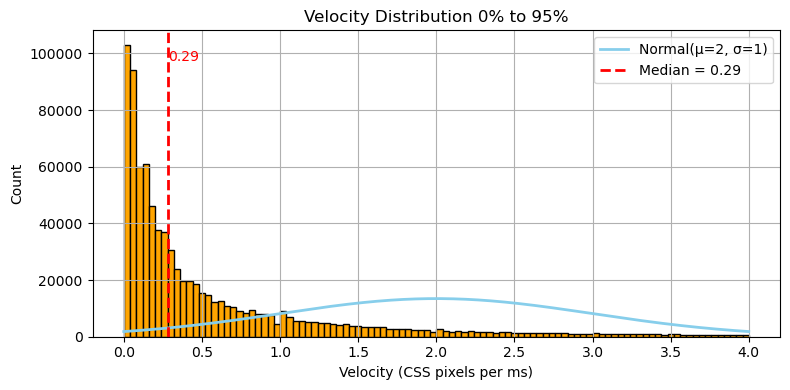

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 
v_iqr1 = velocities[(velocities >= 0) & (velocities <= 4)]
median = np.median(velocities)

# Normal Distribution for comparison
x = np.linspace(0, 4, 500)
mu, sigma = 2.0, 1.0  
normal_pdf = norm.pdf(x, mu, sigma)
normal_pdf_scaled = normal_pdf * (len(v_iqr1) * (4 / 100))  # scale 

# 
plt.figure(figsize=(8, 4))
plt.hist(v_iqr1, bins=100, color='orange', edgecolor='black')

# Normal Curve
plt.plot(x, normal_pdf_scaled, color='skyblue', linewidth=2, label='Normal(μ=2, σ=1)')

# 
plt.axvline(median, color='red', linestyle='--', linewidth=2, label=f'Median = {median:.2f}')
plt.text(median, plt.ylim()[1] * 0.9, f'{median:.2f}', color='red')

# 
plt.title("Velocity Distribution 0% to 95%")
plt.xlabel("Velocity (CSS pixels per ms)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


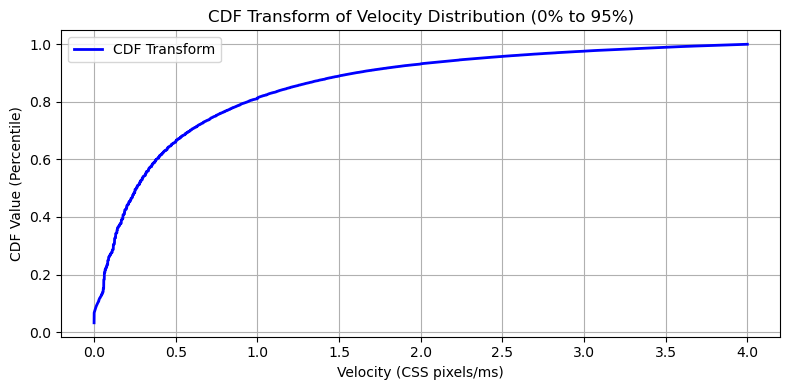

In [9]:
from scipy.stats import rankdata

# Step 1: Compute percentile ranks (CDF transform)
ranks = rankdata(v_iqr1, method='average')  # 1 to N
cdf_values = ranks / len(v_iqr1)  # Normalize to [0, 1]

# Step 2: Sort for plotting
sorted_velocities = np.sort(v_iqr1)
sorted_cdf = np.sort(cdf_values)

# Step 3: Plot CDF transformation curve
plt.figure(figsize=(8, 4))
plt.plot(sorted_velocities, sorted_cdf, color='blue', linewidth=2, label='CDF Transform')
plt.title("CDF Transform of Velocity Distribution (0% to 95%)")
plt.xlabel("Velocity (CSS pixels/ms)")
plt.ylabel("CDF Value (Percentile)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


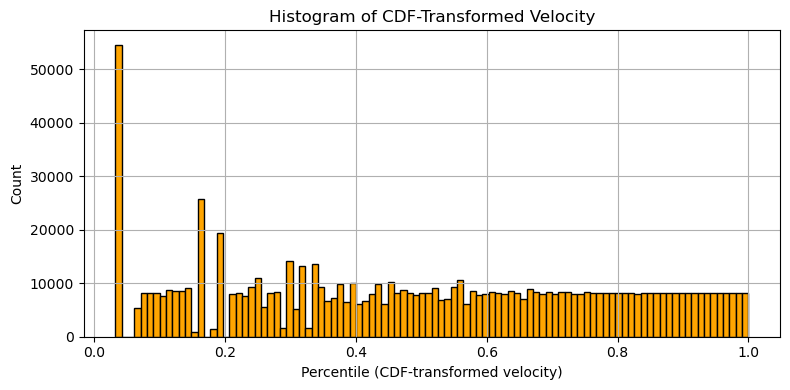

In [12]:
from scipy.stats import rankdata

# Step 1: Compute CDF (percentile) values for velocity
ranks = rankdata(v_iqr1, method='average')  # Rank from 1 to N
cdf_transformed = ranks / len(v_iqr1)       # Normalize to [0, 1]

# Step 2: Plot histogram of percentile values
plt.figure(figsize=(8, 4))
plt.hist(cdf_transformed, bins=100, color='orange', edgecolor='black')

# Step 3: Plot formatting
plt.title("Histogram of CDF-Transformed Velocity")
plt.xlabel("Percentile (CDF-transformed velocity)")
plt.ylabel("Count")
plt.grid(True)
plt.tight_layout()
plt.show()


##  Velocity Encoding via CDF Transformation

### Overview
To enhance the contrast and expressiveness of mouse trajectory images for user authentication, we apply a **CDF-based transformation** to encode velocity values into color intensities. This method ensures that color usage is evenly spread across the full range of the colormap, maximizing visual differentiation of movement patterns.

---

###  Motivation

The raw velocity values computed from mouse trajectories are typically **right-skewed**, meaning:
- Most values are small 
- A few values are large (long tail)

Directly mapping such a distribution to a color map leads to:
- Most points rendered in dark colors
- Minimal color variation
- Poor pattern distinguishability for CNNs

---

### Solution: CDF Transformation

We apply a **cumulative distribution function (CDF) transformation** to the velocity values before color mapping. This method has the following desirable properties:

- **Monotonicity**: Preserves the relative ordering of velocities  
- **One-to-one mapping**: Each unique velocity maps to a unique color  
- **Uniform distribution**: Ensures that transformed values are evenly spread in \([0, 1]\)  

As a result, **color contrast is maximized**, and CNNs can better detect local speed patterns in trajectory images.



In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection
from scipy.stats import rankdata

'''
Uses CDF transformation to encode the velocity and direction of the trajectories.
Takes in binary data from Data/binary folder and saves the trajectories as images in Images/binary_v_cdf
'''

def draw_trajectories_with_velocity_direction_cdf(data_path=None, out_path=None):
    # Get the Sasha root directory -- parent of ImageGeneration folder
    '''
    script_dir = os.path.dirname(os.path.abspath(__file__))
    root_dir = os.path.dirname(script_dir)
    
    if data_path is None:
        data_path = os.path.join(root_dir, 'Data', 'binary')
    if out_path is None:
        out_path = os.path.join(root_dir, 'Images', 'binary_v_cdf')
    
    print(f"Data path: {data_path}")
    print(f"Output path: {out_path}")'''
    
    cmap = plt.get_cmap('plasma')
    os.makedirs(out_path, exist_ok=True)

    for filename in sorted(os.listdir(data_path)):
        if not filename.endswith('.npy'):
            continue

        user_id = filename.replace('.npy', '')
        file_path = os.path.join(data_path, filename)
        save_dir = os.path.join(out_path, f"user{user_id}")
        os.makedirs(save_dir, exist_ok=True)

        print(f"Processing user{user_id}...")

        data = np.load(file_path)

        for i, seq in enumerate(data):
            seq = seq[~np.all(seq == 0, axis=1)]
            if seq.shape[0] < 2:
                continue

            dx = seq[:, 0]
            dy = seq[:, 1]
            dt = seq[:, 2]
            dt[dt == 0] = 1e-5

            xs = np.cumsum(dx)
            ys = np.cumsum(dy)

            velocity = np.sqrt(dx**2 + dy**2) / dt
            velocity += 1e-5  # to avoid exact 0

            try:
                # --- CDF Transformation ---
                ranks = rankdata(velocity, method='average')  # from 1 to N
                trans_velocity = (ranks - 1) / (len(velocity) - 1)  # ∈ [0,1]
            except Exception as e:
                print(f"Skipping trajectory {i} in user{user_id} due to CDF error: {e}")
                continue

            theta = np.arctan2(dy, dx)
            direction_score = 1.0 - np.abs(np.cos(theta[:-1]))
            min_width, max_width = 2.0, 4.0
            linewidths = min_width + direction_score * (max_width - min_width)

            segment_colors = cmap(trans_velocity[:-1])
            point_colors = cmap(trans_velocity)

            points = np.stack([xs, ys], axis=1)
            segments = np.stack([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, colors=segment_colors, linewidths=linewidths)

            fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
            ax.add_collection(lc)
            ax.scatter(xs, ys, c=point_colors, marker='s', s=15, zorder=7)
            ax.plot(xs[0], ys[0], marker='o', color='red', markersize=7, zorder=8)
            ax.plot(xs[-1], ys[-1], marker='x', color='red', markersize=7, zorder=8)

            ax.autoscale()
            ax.margins(x=0.1, y=0.1)
            ax.set_axis_off()
            ax.set_aspect('equal')
            plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

            out_path_img = os.path.join(save_dir, f"user{user_id}_img{i}.png")
            plt.savefig(out_path_img, dpi=100, pad_inches=0.3)
            plt.close(fig)

    print(" All trajectory images saved with CDF velocity transformation + direction encoding.")


if __name__ == "__main__":
    draw_trajectories_with_velocity_direction_cdf("../Data/binary", "../Images/binary_v_cdf")


Processing user0...
Processing user1...
Processing user10...
Processing user11...
Processing user12...
Processing user13...
Processing user14...
Processing user15...
Processing user16...
Processing user17...
Processing user18...
Processing user19...
Processing user2...
Processing user20...
Processing user21...
Processing user22...
Processing user23...
Processing user24...
Processing user25...
Processing user26...
Processing user27...
Processing user28...
Processing user29...
Processing user3...
Processing user30...
Processing user4...
Processing user5...
Processing user6...
Processing user7...
Processing user8...
Processing user9...
 All trajectory images saved with CDF velocity transformation + direction encoding.


**We should clip the velocity to 4**
- Global Min = 0
- Global Max = 4
- Choose a good transformation for velocity to reflect on the normalized scale of [0,4] in colormap

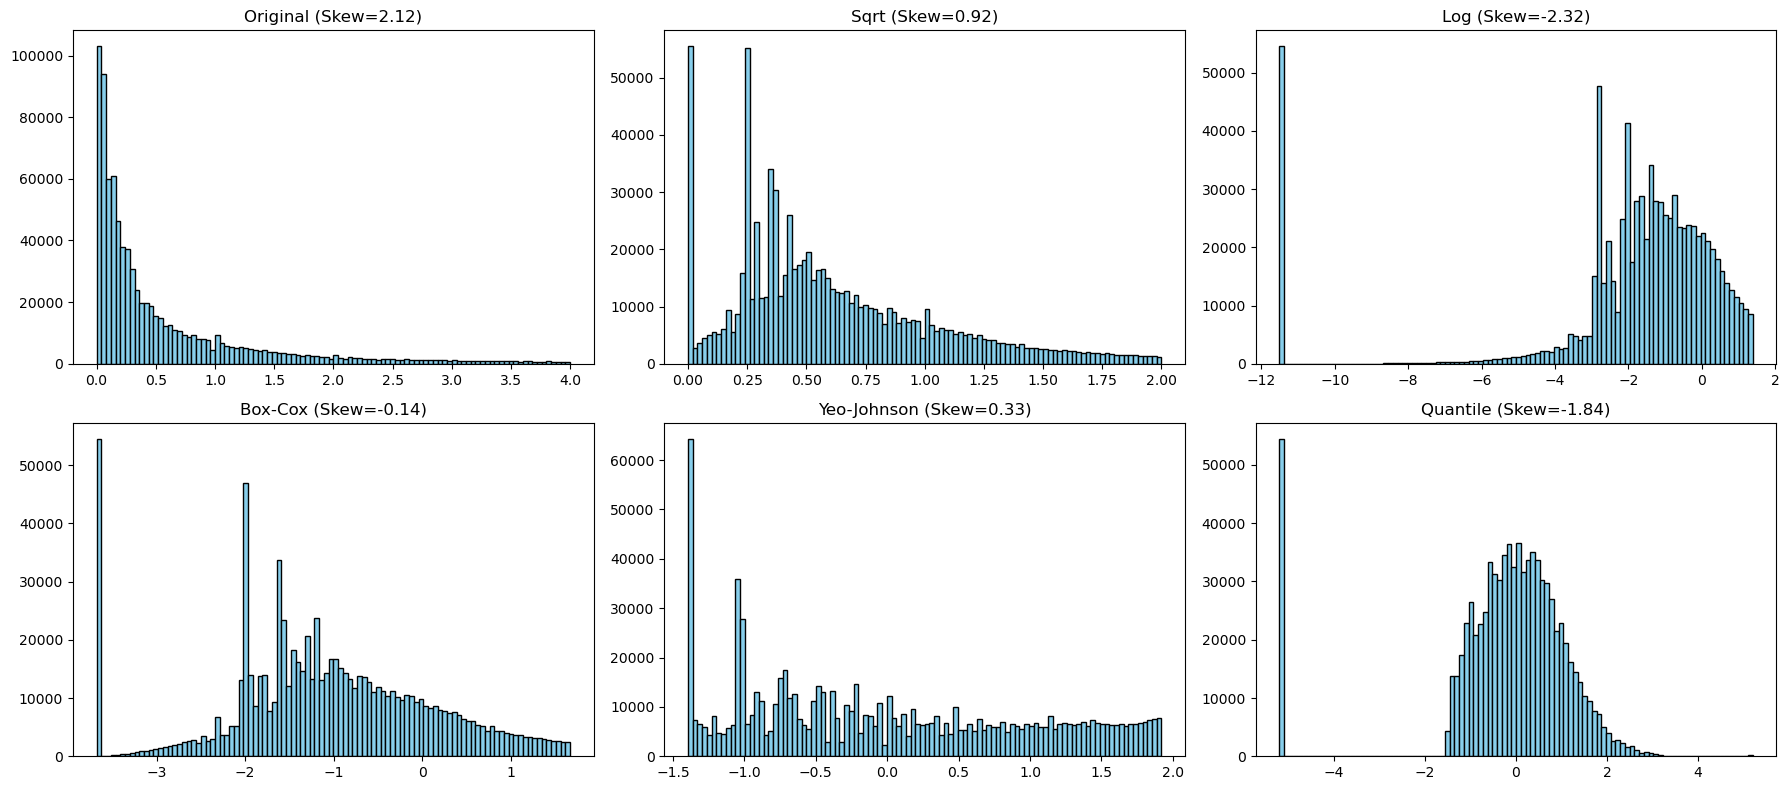

{'Original': 2.1196380858811654, 'Sqrt': 0.9243882906591936, 'Log': -2.320601818061125, 'Box-Cox': -0.13699346180589717, 'Yeo-Johnson': 0.3288032891073928, 'Quantile': -1.839997583759224}


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox, skew
from sklearn.preprocessing import PowerTransformer, QuantileTransformer
import pandas as pd

# Transformations
sqrt_trans = np.sqrt(v_iqr1)
log_trans = np.log(v_iqr1 + 1e-5)
boxcox_trans, _ = boxcox(v_iqr1 + 1e-5)
yeojohnson_trans = PowerTransformer(method='yeo-johnson').fit_transform(v_iqr1.reshape(-1, 1)).flatten()
quantile_trans = QuantileTransformer(output_distribution='normal').fit_transform(v_iqr1.reshape(-1, 1)).flatten()

# Skewness values
skews = {
    'Original': skew(v_iqr1),
    'Sqrt': skew(sqrt_trans),
    'Log': skew(log_trans),
    'Box-Cox': skew(boxcox_trans),
    'Yeo-Johnson': skew(yeojohnson_trans),
    'Quantile': skew(quantile_trans)
}

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
titles = ['Original', 'Sqrt', 'Log', 'Box-Cox', 'Yeo-Johnson', 'Quantile']
transformed_data = [v_iqr1, sqrt_trans, log_trans, boxcox_trans, yeojohnson_trans, quantile_trans]

for ax, title, data in zip(axes.flatten(), titles, transformed_data):
    ax.hist(data, bins=100, color='skyblue', edgecolor='black')
    ax.set_title(f'{title} (Skew={skews[title]:.2f})')

plt.tight_layout()
plt.show()
print(skews)

**Since "Box-Cox" have the skewness nearest to 0, it's closer to normal. We choose it as transformation**

**Now we want to encode direction**

- We will use circle to mark starting point, triangle to mark end point
- We will use linewidth to respresent the direction is closer to horizontal or vertical

**We also apply transformation before color mapping**
- Arctangent
- Box-Cox

In [ ]:
#Arctangent

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection

def draw_trajectories_with_velocity_direction(data_path='./binary', out_path='./image_output_boxcox'):
    cmap = plt.get_cmap('plasma')

    os.makedirs(out_path, exist_ok=True)

    for filename in sorted(os.listdir(data_path)):
        if not filename.endswith('.npy'):
            continue

        user_id = filename.replace('.npy', '')
        file_path = os.path.join(data_path, filename)
        save_dir = os.path.join(out_path, f"user{user_id}")
        os.makedirs(save_dir, exist_ok=True)

        print(f"Processing user{user_id}...")

        data = np.load(file_path)

        for i, seq in enumerate(data):
            seq = seq[~np.all(seq == 0, axis=1)]
            if seq.shape[0] < 2:
                continue

            dx = seq[:, 0]
            dy = seq[:, 1]
            dt = seq[:, 2]
            dt[dt == 0] = 1e-5

            xs = np.cumsum(dx)
            ys = np.cumsum(dy)

            velocity = np.sqrt(dx**2 + dy**2) / dt

            # Boss Cox transformation using arctan + normalization
            trans_velocity = np.arctan(velocity)
            trans_velocity = (trans_velocity - trans_velocity.min()) / (trans_velocity.max() - trans_velocity.min())

            # Direction-based line width encoding
            theta = np.arctan2(dy, dx)
            direction_score = 1.0 - np.abs(np.cos(theta[:-1]))
            min_width, max_width = 2.0, 4.0
            linewidths = min_width + direction_score * (max_width - min_width)

            # Color mapping
            segment_colors = cmap(trans_velocity[:-1])
            point_colors = cmap(trans_velocity)

            # Build line segments
            points = np.stack([xs, ys], axis=1)
            segments = np.stack([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, colors=segment_colors, linewidths=linewidths)

            # Plotting
            fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
            ax.add_collection(lc)
            ax.scatter(xs, ys, c=point_colors, marker='s', s=15, zorder=7)
            ax.plot(xs[0], ys[0], marker='o', color='red', markersize=7, zorder=8)
            ax.plot(xs[-1], ys[-1], marker='x', color='red', markersize=7, zorder=8)

            ax.autoscale()
            ax.margins(x=0.1, y=0.1)
            ax.set_axis_off()
            ax.set_aspect('equal')
            plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

            out_path_img = os.path.join(save_dir, f"user{user_id}_img{i}.png")
            plt.savefig(out_path_img, dpi=100, pad_inches=0.3)
            plt.close(fig)

    print("\\n All trajectory images saved with Boss Cox colormap + direction encoding.")


In [ ]:
draw_trajectories_with_velocity_direction("../Data/binary/" , "../Data/Images/binary_v_arctan/")

Processing user0...
Processing user1...
Processing user10...
Processing user11...
Processing user12...
Processing user13...
Processing user14...
Processing user15...
Processing user16...
Processing user17...
Processing user18...
Processing user19...
Processing user2...
Processing user20...
Processing user21...
Processing user22...
Processing user23...
Processing user24...
Processing user25...
Processing user26...
Processing user27...
Processing user28...
Processing user29...
Processing user3...
Processing user30...
Processing user4...
Processing user5...
Processing user6...
Processing user7...
Processing user8...
Processing user9...
\n All trajectory images saved with Boss Cox colormap + direction encoding.


In [ ]:
#Box-Cox
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.collections import LineCollection
from scipy.stats import boxcox

def draw_trajectories_with_velocity_direction(data_path='./binary', out_path='./image_output_boxcox'):
    cmap = plt.get_cmap('plasma')

    os.makedirs(out_path, exist_ok=True)

    for filename in sorted(os.listdir(data_path)):
        if not filename.endswith('.npy'):
            continue

        user_id = filename.replace('.npy', '')
        file_path = os.path.join(data_path, filename)
        save_dir = os.path.join(out_path, f"user{user_id}")
        os.makedirs(save_dir, exist_ok=True)

        print(f"Processing user{user_id}...")

        data = np.load(file_path)

        for i, seq in enumerate(data):
            seq = seq[~np.all(seq == 0, axis=1)]
            if seq.shape[0] < 2:
                continue

            dx = seq[:, 0]
            dy = seq[:, 1]
            dt = seq[:, 2]
            dt[dt == 0] = 1e-5

            xs = np.cumsum(dx)
            ys = np.cumsum(dy)

            velocity = np.sqrt(dx**2 + dy**2) / dt
            velocity += 1e-5  # Box-Cox requires strictly positive input

            try:
                boxcox_velocity, _ = boxcox(velocity)
                # Normalize to 0~1 for colormap
                trans_velocity = (boxcox_velocity - boxcox_velocity.min()) / (boxcox_velocity.max() - boxcox_velocity.min())
            except Exception as e:
                print(f"Skipping trajectory {i} in user{user_id} due to Box-Cox error: {e}")
                continue

            theta = np.arctan2(dy, dx)
            direction_score = 1.0 - np.abs(np.cos(theta[:-1]))
            min_width, max_width = 2.0, 4.0
            linewidths = min_width + direction_score * (max_width - min_width)

            segment_colors = cmap(trans_velocity[:-1])
            point_colors = cmap(trans_velocity)

            points = np.stack([xs, ys], axis=1)
            segments = np.stack([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, colors=segment_colors, linewidths=linewidths)

            fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
            ax.add_collection(lc)
            ax.scatter(xs, ys, c=point_colors, marker='s', s=15, zorder=7)
            ax.plot(xs[0], ys[0], marker='o', color='red', markersize=7, zorder=8)
            ax.plot(xs[-1], ys[-1], marker='x', color='red', markersize=7, zorder=8)

            ax.autoscale()
            ax.margins(x=0.1, y=0.1)
            ax.set_axis_off()
            ax.set_aspect('equal')
            plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

            out_path_img = os.path.join(save_dir, f"user{user_id}_img{i}.png")
            plt.savefig(out_path_img, dpi=100, pad_inches=0.3)
            plt.close(fig)

    print("\\n All trajectory images saved with true Box-Cox transformation + direction encoding.")


In [68]:
draw_trajectories_with_velocity_direction("../Data/binary/" , "../Data/Images/binary_v_b/")

Processing user0...
Processing user1...
Processing user10...
Processing user11...
Processing user12...
Processing user13...
Processing user14...
Processing user15...
Processing user16...
Processing user17...
Processing user18...
Processing user19...
Processing user2...
Processing user20...
Processing user21...
Processing user22...
Processing user23...
Processing user24...
Processing user25...
Processing user26...
Processing user27...
Processing user28...
Processing user29...
Processing user3...
Processing user30...
Processing user4...
Processing user5...
Processing user6...
Processing user7...
Processing user8...
Processing user9...
\n All trajectory images saved with true Box-Cox transformation + direction encoding.
